eta_0     (z = 0)    = 14146.9 Mpc
eta_star  (z = 1090) = 281.2 Mpc
R(eta_star) = 0.6159
c_s        = 0.45418 c

Grafico salvo com sucesso.


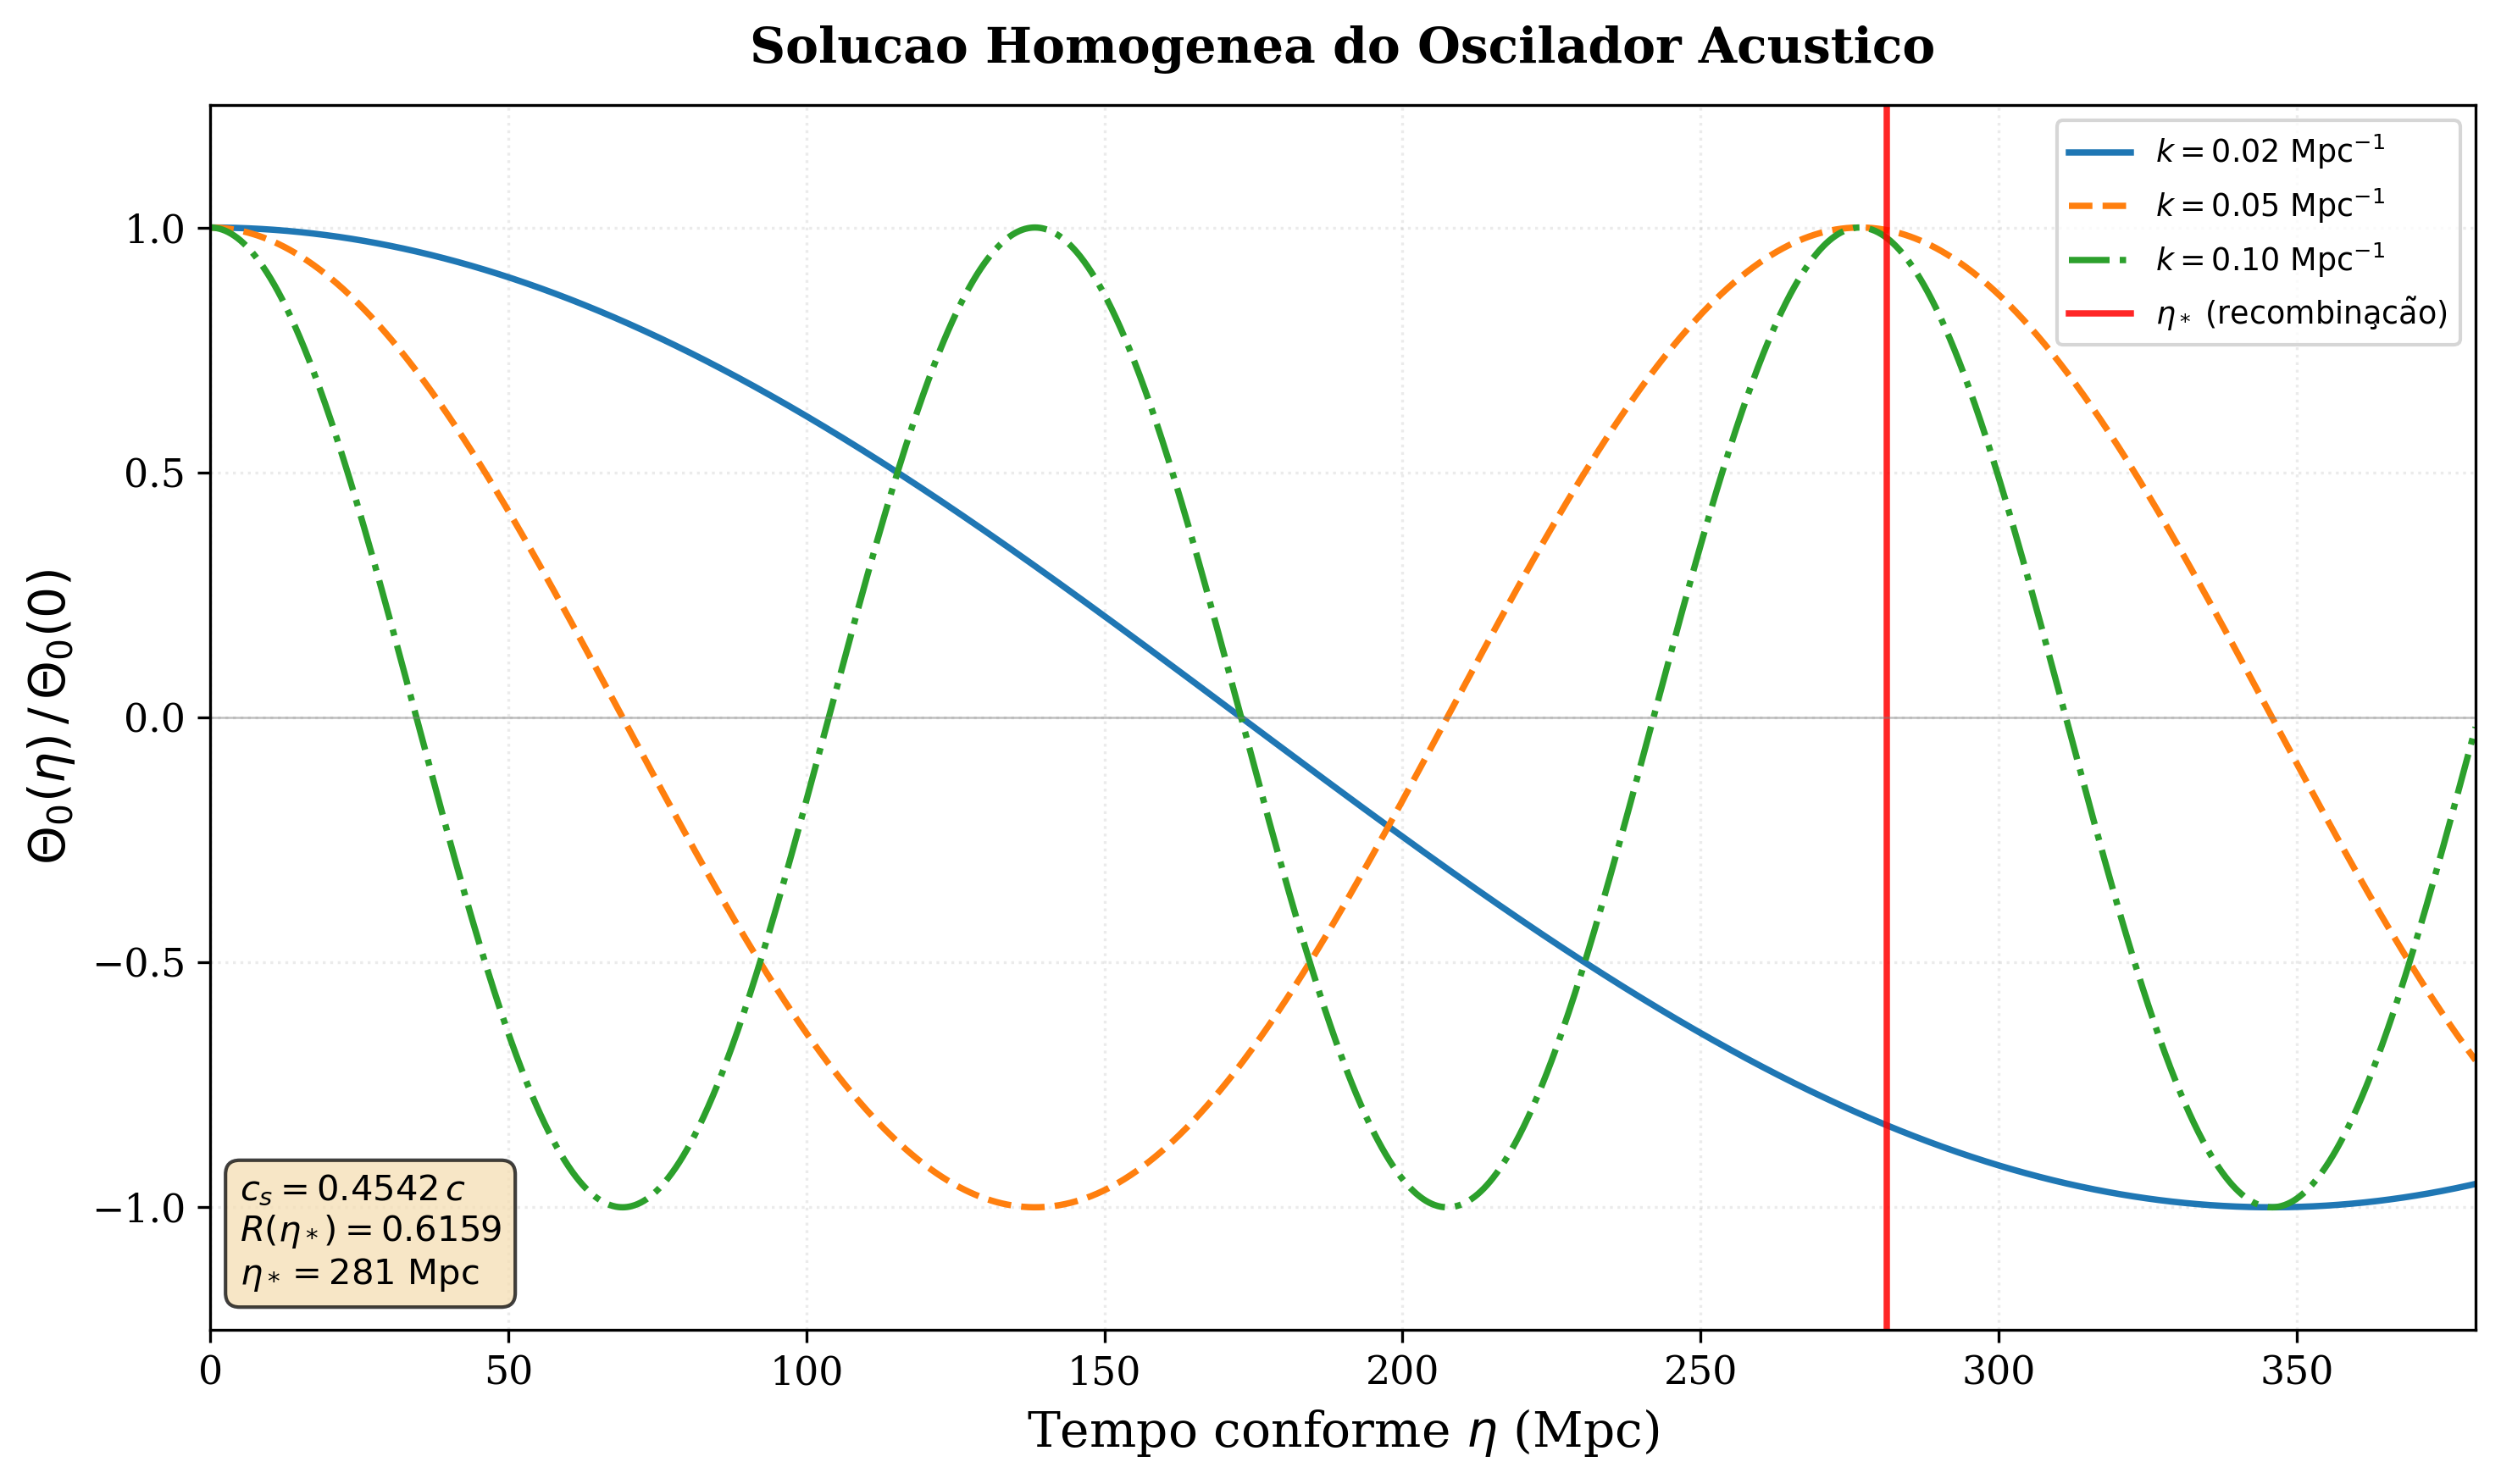


--- Fase das oscilacoes em eta_star = 281.2 Mpc ---
k (Mpc^-1)   fase (rad)   fase/pi    cos      estado
----------------------------------------------------------
0.02         2.554        0.813      -0.832   intermediario
0.05         6.386        2.033      0.995    PICO
0.10         12.772       4.065      0.979    PICO


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate


# =============================================================================
# CONFIGURACOES DE ESTILO
# =============================================================================

plt.style.use('default')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'legend.fontsize': 11,
    'figure.titlesize': 16,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.linewidth': 1.8,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})


# =============================================================================
# PARAMETROS COSMOLOGICOS - Planck 2018
# =============================================================================

Omega_b_h2 = 0.0224
Omega_c_h2 = 0.120
Omega_m    = 0.315
h          = 0.674

H0         = h * 100
c_luz      = 299792.458
H0_si      = H0 / c_luz
Omega_r    = 9.0e-5


z_star = 1090
z_max  = 1e6


# =============================================================================
# TEMPO CONFORME
#
# eta(z) = integral de z ate z_max de dz' / H(z')
# =============================================================================

def eta_conformal(z):

    def integrand(zp):
        E2 = (
            Omega_m * (1 + zp)**3
            + Omega_r * (1 + zp)**4
            + (1 - Omega_m - Omega_r)
        )

        return 1.0 / (H0_si * np.sqrt(E2))

    val, _ = integrate.quad(
        integrand,
        z,
        z_max,
        limit=500
    )

    return val


eta_0    = eta_conformal(0)
eta_star = eta_conformal(z_star)

print(f"eta_0     (z = 0)    = {eta_0:.1f} Mpc")
print(f"eta_star  (z = 1090) = {eta_star:.1f} Mpc")


# =============================================================================
# PARAMETROS DO FLUIDO FOTON-BARION
# =============================================================================

# R(eta_star) - Eq. 74 do TCC
a_star = 1.0 / (1 + z_star)

R_star = 0.6 * (Omega_b_h2 / 0.02) * (a_star / 1e-3)

print(f"R(eta_star) = {R_star:.4f}")


# Velocidade do som para R = R_star - Eq. 77
c_s = 1.0 / np.sqrt(3.0 * (1.0 + R_star))

print(f"c_s        = {c_s:.5f} c")


# A aproximacao r_s = c_s * eta_star considera R aproximadamente constante.
# Nesse caso, obtem-se um valor proximo de 128 Mpc.
#
# Para R(eta) variavel, o horizonte sonico correto e aproximadamente
# r_s = 147 Mpc, conforme a Eq. 82 do TCC.


# =============================================================================
# SOLUCAO HOMOGENEA
#
# Theta_0(eta) / Theta_0(0) = cos(k * c_s * eta)
# =============================================================================

k_values = [0.02, 0.05, 0.10]

k_labels = [
    r'$k = 0.02\ \mathrm{Mpc}^{-1}$',
    r'$k = 0.05\ \mathrm{Mpc}^{-1}$',
    r'$k = 0.10\ \mathrm{Mpc}^{-1}$'
]

linestyles = ['-', '--', '-.']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']


eta_max = 380
eta = np.linspace(0, eta_max, 3000)


# =============================================================================
# GRAFICO
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))


for k, label, linestyle, color in zip(
    k_values,
    k_labels,
    linestyles,
    colors
):

    theta = np.cos(k * c_s * eta)

    ax.plot(
        eta,
        theta,
        label=label,
        linestyle=linestyle,
        color=color,
        linewidth=1.8
    )


# Linha vertical correspondente a eta_star
ax.axvline(
    x=eta_star,
    color='red',
    linestyle='-',
    linewidth=1.8,
    alpha=0.85,
    label=r'$\eta_* \ (\mathrm{recombina\c{c}\tilde{a}o})$'
)


# Linha horizontal em zero
ax.axhline(
    y=0,
    color='gray',
    linestyle='-',
    linewidth=0.6,
    alpha=0.5
)


# Eixos
ax.set_xlabel(
    r'Tempo conforme $\eta$ (Mpc)',
    fontsize=14
)

ax.set_ylabel(
    r'$\Theta_0(\eta)\,/\,\Theta_0(0)$',
    fontsize=14
)

ax.set_xlim(0, eta_max)
ax.set_ylim(-1.25, 1.25)

ax.tick_params(labelsize=11)


# Legenda
ax.legend(
    loc='upper right',
    frameon=True,
    fancybox=True,
    fontsize=8.75
)


# Informacoes no interior do grafico
ax.text(
    0.013,
    0.03,
    rf'$c_s = {c_s:.4f}\,c$' '\n'
    rf'$R(\eta_*) = {R_star:.4f}$' '\n'
    rf'$\eta_* = {eta_star:.0f}\ \mathrm{{Mpc}}$',
    transform=ax.transAxes,
    bbox=dict(
        boxstyle='round',
        facecolor='wheat',
        alpha=0.75,
        pad=0.4
    ),
    fontsize=10,
    verticalalignment='bottom'
)


ax.set_title(
    'Solucao Homogenea do Oscilador Acustico',
    fontsize=14,
    fontweight='bold',
    pad=12
)


ax.grid(
    True,
    alpha=0.25,
    linestyle=':'
)


plt.tight_layout()


# Salva o grafico em dois formatos
plt.savefig(
    'grafico1_oscilador_homogeneo_final.png',
    dpi=300,
    bbox_inches='tight'
)

plt.savefig(
    'grafico1_oscilador_homogeneo_final.pdf',
    dpi=300,
    bbox_inches='tight'
)

print("\nGrafico salvo com sucesso.")


plt.show()


# =============================================================================
# VERIFICACAO DOS PICOS EM eta_star
# =============================================================================

print(
    f"\n--- Fase das oscilacoes em eta_star = "
    f"{eta_star:.1f} Mpc ---"
)

print(
    f"{'k (Mpc^-1)':<12} "
    f"{'fase (rad)':<12} "
    f"{'fase/pi':<10} "
    f"{'cos':<8} "
    f"{'estado'}"
)

print("-" * 58)


for k in k_values:

    fase = k * c_s * eta_star
    valor = np.cos(fase)
    n_pi = fase / np.pi

    if abs(valor) > 0.9:
        estado = "PICO"

    elif abs(valor) < 0.15:
        estado = "NO"

    else:
        estado = "intermediario"

    print(
        f"{k:<12.2f} "
        f"{fase:<12.3f} "
        f"{n_pi:<10.3f} "
        f"{valor:<8.3f} "
        f"{estado}"
    )